In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [62]:
# extraer datos de ventas.csv
df_ventas = pd.read_csv("ventas.csv")

In [63]:
# Exploracion de los datos

print(df_ventas.head()) # Muestra las primeras 5 filas del DataFrame

# Si hay datos nulos, se puede eliminar la fila o columna que contenga el dato nulo, o reemplazarlo por un valor.

# En este caso se eliminaran las filas que contengan datos nulos.

df_ventas = df_ventas.dropna()

        fecha  id_cliente    producto    categoria  cantidad  precio_unitario  \
0  2023-01-01           7  Producto D  Categoría 3      33.0              400   
1  2023-01-07           5  Producto G  Categoría 3      23.0              350   
2  2023-01-13           8  Producto E  Categoría 2      40.0              400   
3  2023-01-19           6  Producto E  Categoría 2       6.0              400   
4  2023-01-25           6  Producto B  Categoría 2      25.0               50   

     region  
0  Región 1  
1  Región 3  
2  Región 3  
3  Región 2  
4  Región 2  


In [64]:
# Convertir fecha a tipo datetime
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])

# Si precio unitario es negativo, se reemplaza por el valor absoluto
print(df_ventas.columns.tolist())


['fecha', 'id_cliente', 'producto', 'categoria', 'cantidad', 'precio_unitario', 'region']


In [65]:
# Valor absoluto de precio unitario
df_ventas['precio_unitario'] = df_ventas['precio_unitario'].abs()

# Si es cero se pone la media de los precios unitarios
media_precio_unitario = df_ventas['precio_unitario'].mean()
df_ventas['precio_unitario'] = df_ventas['precio_unitario'].replace(0, media_precio_unitario)

In [66]:
# Agregar total de precio por venta (precio_unitario * cantidad)
df_ventas['total_venta'] = df_ventas['precio_unitario'] * df_ventas['cantidad']

In [67]:
"""
Calcula el total de ventas por región y por mes.
Encuentra el top 5 de productos con mayor ingreso total.
Calcula el ticket promedio por cliente (total_venta / número de compras).}
"""

print(df_ventas.head())

# Extraer mes para agrupar
df_ventas['mes'] = df_ventas['fecha'].dt.to_period('M')

       fecha  id_cliente    producto    categoria  cantidad  precio_unitario  \
0 2023-01-01           7  Producto D  Categoría 3      33.0            400.0   
1 2023-01-07           5  Producto G  Categoría 3      23.0            350.0   
2 2023-01-13           8  Producto E  Categoría 2      40.0            400.0   
3 2023-01-19           6  Producto E  Categoría 2       6.0            400.0   
4 2023-01-25           6  Producto B  Categoría 2      25.0             50.0   

     region  total_venta  
0  Región 1      13200.0  
1  Región 3       8050.0  
2  Región 3      16000.0  
3  Región 2       2400.0  
4  Región 2       1250.0  


In [68]:
# 1. Total de ventas por región y por mes
ventas_region_mes = df_ventas.groupby(['region', 'mes'])['total_venta'].sum().reset_index()
print("Ventas por región y mes:")
print(ventas_region_mes)

Ventas por región y mes:
      region      mes   total_venta
0   Región 1  2023-01  13200.000000
1   Región 1  2023-02   9250.000000
2   Región 1  2023-03  11200.000000
3   Región 1  2023-04  35150.000000
4   Región 1  2023-05  22350.000000
5   Región 1  2023-06   8600.000000
6   Región 2  2023-01   3650.000000
7   Región 2  2023-02   3600.000000
8   Región 2  2023-03  24437.931034
9   Región 2  2023-05   5200.000000
10  Región 2  2023-06  13800.000000
11  Región 3  2023-01  24050.000000
12  Región 3  2023-02  51700.000000
13  Región 3  2023-04  21000.000000
14  Región 3  2023-06  27550.000000


In [69]:
# 2. Top 5 productos con mayor ingreso total
top5_productos = (
    df_ventas.groupby('producto')['total_venta']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print("\nTop 5 productos por ingreso:")
print(top5_productos)


Top 5 productos por ingreso:
producto
Producto G    57850.0
Producto J    50050.0
Producto A    42350.0
Producto E    40050.0
Producto I    37500.0
Name: total_venta, dtype: float64


In [70]:
# 3. Ticket promedio por cliente (total_venta / número de compras)
ticket_promedio_cliente = (
    df_ventas.groupby('id_cliente')['total_venta']
    .agg(total='sum', num_compras='count')
)
ticket_promedio_cliente['ticket_promedio'] = (
    ticket_promedio_cliente['total'] / ticket_promedio_cliente['num_compras']
)
print("\nTicket promedio por cliente:")
print(ticket_promedio_cliente)


Ticket promedio por cliente:
                   total  num_compras  ticket_promedio
id_cliente                                            
1           10800.000000            1     10800.000000
2           47700.000000            4     11925.000000
3           38550.000000            4      9637.500000
5           40050.000000            4     10012.500000
6           30150.000000            3     10050.000000
7           41600.000000            5      8320.000000
8           37837.931034            4      9459.482759
9           22250.000000            3      7416.666667
10           5800.000000            1      5800.000000


In [71]:
# Método de rango intercuartílico (IQR) para 'total_venta'

Q1 = df_ventas['total_venta'].quantile(0.25)
Q3 = df_ventas['total_venta'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite inferior: {limite_inferior}, Límite superior: {limite_superior}")


Q1: 3600.0, Q3: 13200.0, IQR: 9600.0
Límite inferior: -10800.0, Límite superior: 27600.0


In [72]:
# Identificar los valores atípicos
outliers = df_ventas[
    (df_ventas['total_venta'] < limite_inferior) |
    (df_ventas['total_venta'] > limite_superior)
]

print(f"\nCantidad de outliers encontrados: {len(outliers)}")
print(outliers)


Cantidad de outliers encontrados: 0
Empty DataFrame
Columns: [fecha, id_cliente, producto, categoria, cantidad, precio_unitario, region, total_venta, mes]
Index: []


In [73]:
# Tabla pivote: total de ventas por región (filas) y categoría (columnas)
pivote_region_categoria = df_ventas.pivot_table(
    values='total_venta',
    index='region',
    columns='categoria',
    aggfunc='sum',
    fill_value=0
)

print(pivote_region_categoria)

categoria  Categoría 1  Categoría 2   Categoría 3
region                                           
Región 1       23900.0      25550.0  50300.000000
Región 2       14700.0       7250.0  28737.931034
Región 3       47500.0      16000.0  60800.000000


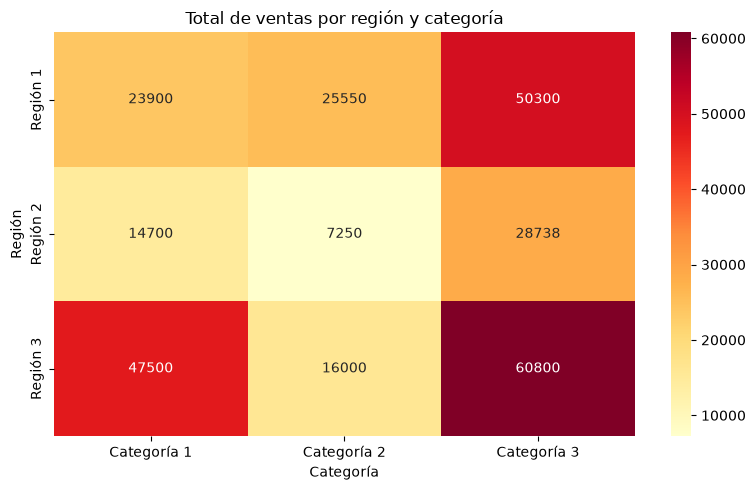

In [74]:
# Visualización 1: Heatmap de ventas por región y categoría
plt.figure(figsize=(8, 5))
sns.heatmap(
    pivote_region_categoria,
    annot=True,      # muestra los valores numéricos en cada celda
    fmt='.0f',
    cmap='YlOrRd'
)
plt.title('Total de ventas por región y categoría')
plt.xlabel('Categoría')
plt.ylabel('Región')
plt.tight_layout()
plt.show()

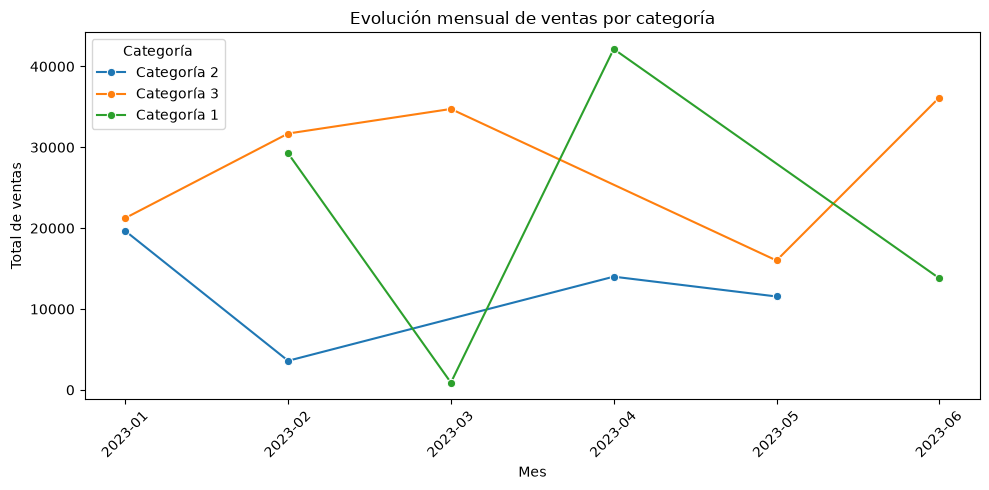

In [75]:
# Visualización 2: Evolución temporal por categoría
ventas_categoria_mes = (
    df_ventas.groupby(['mes', 'categoria'])['total_venta']
    .sum()
    .reset_index()
)

# Convertir 'mes' (Period) a algo graficable en el eje X
ventas_categoria_mes['mes'] = ventas_categoria_mes['mes'].astype(str)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=ventas_categoria_mes,
    x='mes',
    y='total_venta',
    hue='categoria',
    marker='o'
)
plt.title('Evolución mensual de ventas por categoría')
plt.xlabel('Mes')
plt.ylabel('Total de ventas')
plt.xticks(rotation=45)
plt.legend(title='Categoría')
plt.tight_layout()
plt.show()